# **Catch Me If You Can Network Analysis**

**Group:** H

**Group members:**  
- Andrea Cipolla - ID 319211  
- Arianna Cambi - ID 317971  
- Sofia Capriolo - ID 309371  
- Giorgio Vanini - ID 311581  
- Maiia Kopalina - ID 321891  

## **Introduction**

This project applies **Social Network Analysis (SNA)** to the movie *Catch Me If You Can*. The objective is to study the structure of interactions between characters by representing them as a network and analyzing its structural properties using computational tools.

**Network:** *Catch Me If You Can* movie network  
**Type:** undirected, weighted social network  
**Meaning of nodes:** characters appearing in the movie  
**Meaning of edges:** two characters appear in the same scene  
**Meaning of weights:** number of scenes in which the two characters appear together

**Source:** J. Kaminski et al., *Moviegalaxies - Social Networks in Movies*, Harvard Dataverse, V3 (2018).

### **Project Goals**

In this representation, characters are modeled as nodes in a network, while their interactions are captured through edges connecting characters who appear in the same scene. The weight associated with each edge reflects the intensity of interaction, measured by the number of shared-scene appearances.

The aim of the project is to explore the structure of this network through several Social Network Analysis techniques, including:
- graph construction and visualization
- computation of basic network statistics
- clustering analysis and clustering distributions
- centrality measures
- community detection methods
- link prediction
- random graph modeling
- contagion and spreading dynamics

### **Structure of the Analysis**

The analysis is organized following the weekly assignments of the course:
- **Week 1:** graph implementation, visualization, and computation of basic statistics
- **Week 2:** computation of clustering coefficients and comparison with built-in functions
- **Week 3:** analysis of cumulative distributions related to clustering
- **Week 5:** identification of the most central nodes using centrality measures
- **Week 6:** detection of communities using different algorithms and comparison of their results
- **Week 7:** link prediction using Common Neighbors and Adamic-Adar indices
- **Week 9:** comparison with a random graph model based on preferential attachment with triad closure
- **Week 10:** simulation of a SIR contagion model and investigation of different outbreak scenarios

### **Background**

Although the dataset represents a fictional narrative, it provides a meaningful example of a social structure where certain characters play central roles in connecting different parts of the story while others remain more peripheral.

The analysis is organized according to the weekly tasks assigned during the course. First, the graph is implemented and described through basic network statistics. Then, the analysis focuses on local cohesion through clustering coefficients and their distributions. Next, centrality measures identify the most important characters and community detection methods reveal tightly connected subgroups. The later weeks extend the analysis further: link prediction estimates which co-scene appearances are most likely to be missing from the data, a random graph model tests how well preferential attachment with triad closure reproduces the network's structural properties, and a SIR contagion model investigates how information or rumours could spread across the cast under different conditions.

Overall, this project combines computational implementation and interpretation, showing how network-based methods can reveal meaningful insights about the internal structure of a narrative system.

## Week 1

In this first part, we load the selected social network and represent it as a graph in Python using the NetworkX library. We then visualize the network and compute basic descriptive measures such as the number of nodes, edges, average degree, and density.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import random

# allow display both in notebooks and scripts
try:
    from IPython.display import display
    from IPython import get_ipython
except ImportError:
    def display(obj):
        print(obj)

    def get_ipython():
        return None

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")  # show plots inside notebook

# plotting style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

# dataset paths
NODES_PATH = Path("nodes.csv")
EDGES_PATH = Path("edges.csv")

# load node and edge tables
nodes_df = pd.read_csv(NODES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

# clean column names (remove extra spaces)
nodes_df.columns = [col.strip() for col in nodes_df.columns]
edges_df.columns = [col.strip() for col in edges_df.columns]

# create empty graph
G = nx.Graph()

# add nodes with character labels
for _, row in nodes_df.iterrows():
    G.add_node(int(row["# index"]), label=str(row["label"]).strip())

# add edges with weights (scene co-occurrence strength)
for _, row in edges_df.iterrows():
    G.add_edge(int(row["# source"]), int(row["target"]), weight=float(row["weight"]))

# quick check of graph size
print(f"Nodes loaded: {G.number_of_nodes()}")
print(f"Edges loaded: {G.number_of_edges()}")

# preview of datasets
display(nodes_df.head())
display(edges_df.head())

Nodes loaded: 82
Edges loaded: 162


,# index,label,movie_id
0,0,AGENT AMDURSKY,180
1,1,AMDURSKY,180
2,2,ASHLEY,180
3,3,AUCTIONEER,180
4,4,BARTENDER,180


,# source,target,label,movie_id,weight
0,0,20,37180,180,1
1,0,1,37176,180,1
2,0,34,37178,180,1
3,1,70,37265,180,1
4,1,20,37210,180,2


### Graph visualization

The dataset available in this folder does not include predefined plotting coordinates, so the graph is drawn with a force-directed layout (`spring_layout`). This still provides a valid visual overview of the network structure.

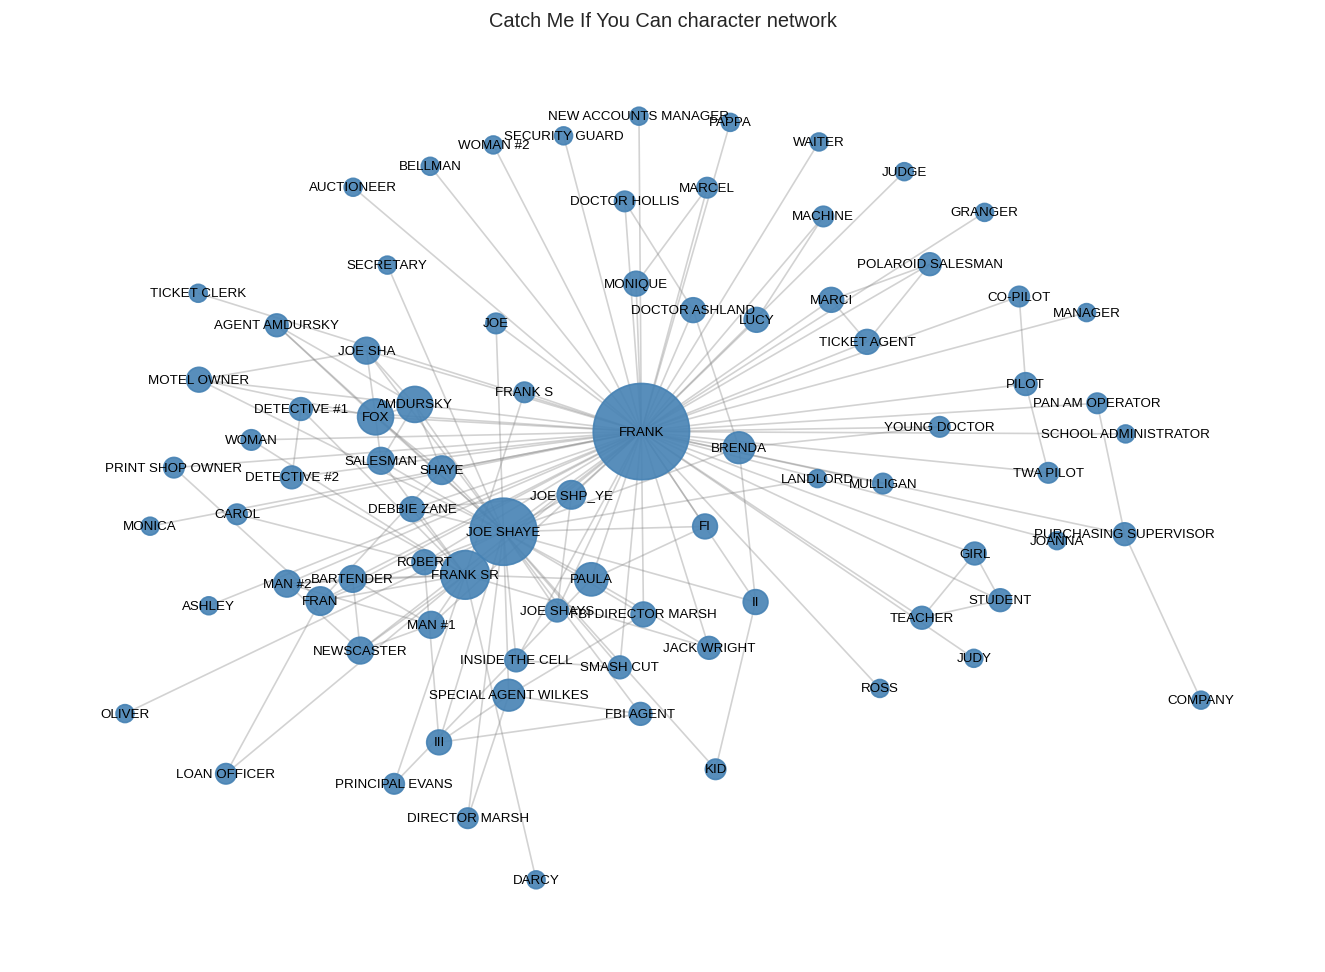

In [2]:
plt.figure(figsize=(14, 10))

# spring layout to position nodes
layout = nx.spring_layout(G, seed=42, k=0.45)

# weighted degree used to scale node sizes
weighted_degree = dict(G.degree(weight='weight'))
node_sizes = [80 + 35 * weighted_degree[node] for node in G.nodes()]

# draw edges
nx.draw_networkx_edges(G, pos=layout, alpha=0.35, edge_color='gray')

# draw nodes
nx.draw_networkx_nodes(G, pos=layout, node_size=node_sizes, node_color='steelblue', alpha=0.9)

# add character labels
nx.draw_networkx_labels(
    G,
    pos=layout,
    labels={node: data['label'] for node, data in G.nodes(data=True)},
    font_size=8,
)

plt.title('Catch Me If You Can character network')
plt.axis('off')
plt.show()

### Basic network statistics

In [3]:
# basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# average degree of the network
average_degree = sum(dict(G.degree()).values()) / num_nodes

# network density
density = nx.density(G)

summary_week1 = pd.DataFrame(
    {
        'metric': ['Number of nodes', 'Number of edges', 'Average degree', 'Density'],
        'value': [num_nodes, num_edges, average_degree, density],
    }
)

summary_week1

,metric,value
0,Number of nodes,82.00000
1,Number of edges,162.00000
2,Average degree,3.95122
3,Density,0.04878


### Comment
The graph contains **82 nodes and 162 edges**, with an **average degree of approximately 3.95** — each character shares scenes with about four others on average. The **density of 0.049** confirms that the network is sparse: only a small fraction of all possible connections exist. This is typical of character interaction networks, where most roles interact with a limited subset of the cast rather than with the entire ensemble.

## Week 2

In this part, we restrict the analysis to the **largest connected component** of the network and study its local cohesion through clustering measures. We implement a custom function to compute the clustering coefficient of each node, then use it to calculate the average clustering and compare the result with the corresponding built-in NetworkX measures.

In [4]:
# work on the largest connected component
if nx.is_connected(G):
    G_lcc = G.copy()
else:
    largest_component_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_component_nodes).copy()

print(f'Largest connected component: {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges')

Largest connected component: 82 nodes, 162 edges


In [5]:
# manual computation of node clustering coefficients
def local_clustering_manual(graph):
    clustering = {}

    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        k = len(neighbors)

        # nodes with fewer than two neighbors cannot form triangles
        if k < 2:
            clustering[node] = 0.0
            continue

        closed_triplets = 0
        for u, v in combinations(neighbors, 2):
            if graph.has_edge(u, v):
                closed_triplets += 1

        # clustering coefficient formula
        clustering[node] = closed_triplets / (k * (k - 1) / 2)

    return clustering


# compute average clustering manually
def average_clustering_manual(graph):
    clustering_values = local_clustering_manual(graph)
    return sum(clustering_values.values()) / len(clustering_values)


# manual measures
manual_clustering = local_clustering_manual(G_lcc)
manual_average_clustering = average_clustering_manual(G_lcc)

# NetworkX built-in measures for comparison
networkx_average_clustering = nx.average_clustering(G_lcc)
networkx_transitivity = nx.transitivity(G_lcc)

comparison_week2 = pd.DataFrame(
    {
        'measure': [
            'Manual average clustering',
            'NetworkX average clustering',
            'NetworkX transitivity',
        ],
        'value': [
            manual_average_clustering,
            networkx_average_clustering,
            networkx_transitivity,
        ],
    }
)

comparison_week2

,measure,value
0,Manual average clustering,0.599051
1,NetworkX average clustering,0.599051
2,NetworkX transitivity,0.114656


### Comment

The results confirm that the custom implementation is correct, since the **manual average clustering** exactly matches the value returned by `nx.average_clustering()`, both equal to about **0.599**. This indicates a relatively high tendency of characters to form locally connected groups, meaning that if two characters are connected to the same one, they are often also connected to each other. By contrast, the **transitivity** is much lower, about **0.115**, because it is a global measure based on all triplets in the network rather than the average of local node-level coefficients. The difference between the two values suggests that triangle closure is not distributed uniformly across all characters, but is stronger around some nodes than others.

## Week 3

In this part, we analyze how clustering is distributed across the largest connected component. We first compute the **cumulative distribution of node clustering coefficients**, then define for each node the average clustering of its neighbors and compute the cumulative distribution of this second quantity in order to compare the two patterns.

In [6]:
# empirical cumulative distribution function
def empirical_cdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    cumulative = np.arange(1, len(values) + 1) / len(values)
    return values, cumulative


# clustering values of nodes
clustering_values = list(manual_clustering.values())

# compute CDF of clustering coefficients
clustering_x, clustering_cdf = empirical_cdf(clustering_values)

In [7]:
# compute average clustering of neighbors for each node
def average_neighbor_clustering(graph, clustering_by_node):
    neighbor_average = {}

    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        if not neighbors:
            neighbor_average[node] = 0.0
            continue

        # average clustering among neighbors
        neighbor_average[node] = float(np.mean([clustering_by_node[neighbor] for neighbor in neighbors]))

    return neighbor_average


# compute neighbor clustering values
neighbor_clustering = average_neighbor_clustering(G_lcc, manual_clustering)

neighbor_values = list(neighbor_clustering.values())

# CDF of neighbors' average clustering
neighbor_x, neighbor_cdf = empirical_cdf(neighbor_values)

# table of nodes ranked by neighbors' clustering
neighbor_clustering_df = pd.DataFrame(
    {
        'node': list(neighbor_clustering.keys()),
        'label': [G_lcc.nodes[node]['label'] for node in neighbor_clustering.keys()],
        'avg_neighbor_clustering': list(neighbor_clustering.values()),
    }
).sort_values('avg_neighbor_clustering', ascending=False)

neighbor_clustering_df.head(10)

,node,label,avg_neighbor_clustering
24,24,FRANK SR,0.780214
25,25,GIRL,0.676768
60,60,POLAROID SALESMAN,0.676768
59,59,PILOT,0.676768
74,74,TEACHER,0.676768
73,73,STUDENT,0.676768
75,75,TICKET AGENT,0.676768
48,48,MARCI,0.676768
34,34,JOE SHAYE,0.673021
72,72,SPECIAL AGENT WILKES,0.655026


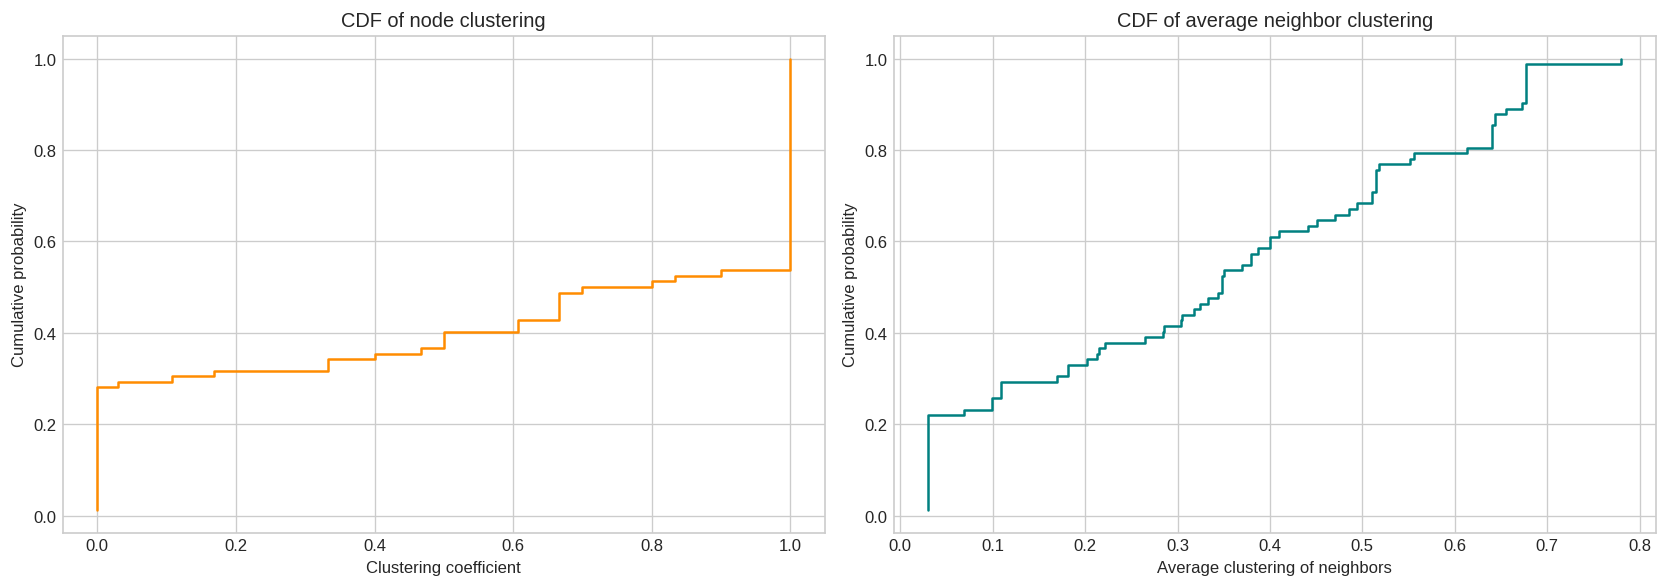

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(clustering_x, clustering_cdf, where='post', color='darkorange')
axes[0].set_title('CDF of node clustering')
axes[0].set_xlabel('Clustering coefficient')
axes[0].set_ylabel('Cumulative probability')

axes[1].step(neighbor_x, neighbor_cdf, where='post', color='teal')
axes[1].set_title('CDF of average neighbor clustering')
axes[1].set_xlabel('Average clustering of neighbors')
axes[1].set_ylabel('Cumulative probability')

plt.tight_layout()
plt.show()

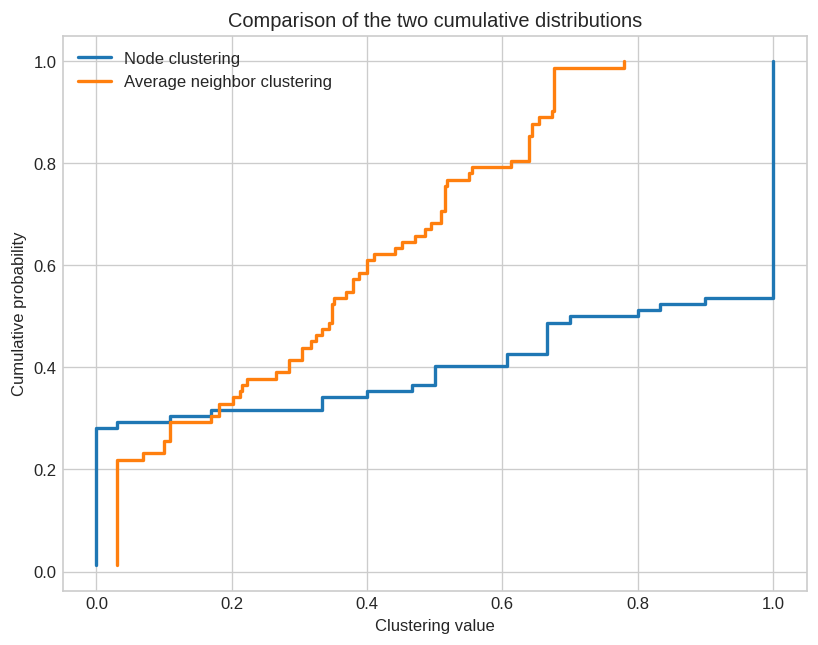

In [9]:
plt.figure(figsize=(8, 6))
plt.step(clustering_x, clustering_cdf, where='post', label='Node clustering', linewidth=2)
plt.step(neighbor_x, neighbor_cdf, where='post', label='Average neighbor clustering', linewidth=2)
plt.xlabel('Clustering value')
plt.ylabel('Cumulative probability')
plt.title('Comparison of the two cumulative distributions')
plt.legend()
plt.show()

In [10]:
# summary statistics for the comparison
clustering_values_df = pd.DataFrame({'clustering': clustering_values})
avg_neighbor_clust_df = neighbor_clustering_df.copy()

comparison_summary = pd.DataFrame({
    "Measure": [
        "Mean node clustering",
        "Median node clustering",
        "Mean neighbors' average clustering",
        "Median neighbors' average clustering"
    ],
    "Value": [
        clustering_values_df["clustering"].mean(),
        clustering_values_df["clustering"].median(),
        avg_neighbor_clust_df["avg_neighbor_clustering"].mean(),
        avg_neighbor_clust_df["avg_neighbor_clustering"].median()
    ]
})

comparison_summary

,Measure,Value
0,Mean node clustering,0.599051
1,Median node clustering,0.750000
2,Mean neighbors' average clustering,0.338559
3,Median neighbors' average clustering,0.348485


### Comment

The comparison between the two cumulative distributions shows that **node clustering coefficients** are generally higher than the **average clustering of neighbors**. This is also confirmed by the summary statistics: the mean node clustering is about **0.599**, while the mean neighbors’ average clustering is only about **0.339**. In other words, many characters belong to locally cohesive groups, but their neighbors are not, on average, embedded in equally clustered neighborhoods. The higher median node clustering **(0.75)** reinforces the idea that triangle closure is relatively common around individual characters, whereas the lower median neighbor value **(about 0.348)** suggests a less cohesive local environment when looking one step away. Overall, the two distributions indicate that clustering is present in the network but is not distributed uniformly across neighborhoods.

## Week 5

In this part we analyze node importance using two centrality measures: **betweenness centrality** and **PageRank**. Betweenness identifies characters that act as bridges connecting different parts of the network, while PageRank measures global importance based on connections to already influential nodes. We implement PageRank manually and compare the results with the built-in NetworkX function as a validation step.

In [11]:
# convert edge weights into distances for shortest-path calculations
for u, v, data in G.edges(data=True):
    data['distance'] = 1.0 / data['weight']


# manual implementation of weighted PageRank
def pagerank_manual(graph, alpha=0.85, max_iter=200, tol=1.0e-9):
    nodes = list(graph.nodes())
    n = len(nodes)

    # initial uniform rank
    rank = {node: 1.0 / n for node in nodes}

    # weighted degree (used to normalize transitions)
    weighted_degree = {
        node: sum(data.get('weight', 1.0) for _, _, data in graph.edges(node, data=True))
        for node in nodes
    }

    for _ in range(max_iter):
        new_rank = {node: (1.0 - alpha) / n for node in nodes}

        # handle dangling nodes
        dangling_sum = sum(rank[node] for node in nodes if weighted_degree[node] == 0)
        dangling_contribution = alpha * dangling_sum / n
        for node in nodes:
            new_rank[node] += dangling_contribution

        # distribute rank through outgoing edges
        for source in nodes:
            if weighted_degree[source] == 0:
                continue
            for target in graph.neighbors(source):
                weight = graph[source][target].get('weight', 1.0)
                new_rank[target] += alpha * rank[source] * (weight / weighted_degree[source])

        error = sum(abs(new_rank[node] - rank[node]) for node in nodes)
        rank = new_rank
        if error < tol:
            break

    return rank


# compute centrality measures
betweenness_scores = nx.betweenness_centrality(G, weight='distance')
pagerank_scores = pagerank_manual(G)

In [12]:
# validate the manual PageRank against NetworkX
networkx_pagerank = nx.pagerank(G, weight='weight')

pagerank_validation = pd.DataFrame(
    {
        'node': list(G.nodes()),
        'label': [G.nodes[node]['label'] for node in G.nodes()],
        'manual_pagerank': [pagerank_scores[node] for node in G.nodes()],
        'networkx_pagerank': [networkx_pagerank[node] for node in G.nodes()],
    }
)

pagerank_validation['abs_difference'] = (
    pagerank_validation['manual_pagerank'] - pagerank_validation['networkx_pagerank']
).abs()

pagerank_validation.sort_values('abs_difference', ascending=False).head(10)

,node,label,manual_pagerank,networkx_pagerank,abs_difference
22,22,FRANK,0.223140,0.223155,0.000015
34,34,JOE SHAYE,0.092136,0.092126,0.000010
1,1,AMDURSKY,0.022033,0.022030,0.000003
20,20,FOX,0.022033,0.022030,0.000003
72,72,SPECIAL AGENT WILKES,0.017484,0.017482,0.000003
63,63,PURCHASING SUPERVISOR,0.011065,0.011067,0.000002
24,24,FRANK SR,0.049460,0.049462,0.000002
33,33,JOE SHA,0.010939,0.010938,0.000002
70,70,SHAYE,0.012866,0.012864,0.000001
51,51,MOTEL OWNER,0.008874,0.008873,0.000001


In [13]:
# build table with centrality measures
centrality_df = pd.DataFrame(
    {
        'node': list(G.nodes()),
        'label': [G.nodes[node]['label'] for node in G.nodes()],
        'betweenness': [betweenness_scores[node] for node in G.nodes()],
        'pagerank': [pagerank_scores[node] for node in G.nodes()],
    }
)

# compute ranking positions
centrality_df['betweenness_rank'] = centrality_df['betweenness'].rank(ascending=False, method='min')
centrality_df['pagerank_rank'] = centrality_df['pagerank'].rank(ascending=False, method='min')

# combined ranking score
centrality_df['combined_rank_score'] = centrality_df['betweenness_rank'] + centrality_df['pagerank_rank']

centrality_df.sort_values('combined_rank_score').head(10)

,node,label,betweenness,pagerank,betweenness_rank,pagerank_rank,combined_rank_score
22,22,FRANK,0.877958,0.223140,1.0,1.0,2.0
34,34,JOE SHAYE,0.317104,0.092136,2.0,2.0,4.0
24,24,FRANK SR,0.081019,0.049460,3.0,3.0,6.0
1,1,AMDURSKY,0.000489,0.022033,5.0,4.0,9.0
20,20,FOX,0.000489,0.022033,5.0,4.0,9.0
72,72,SPECIAL AGENT WILKES,0.000309,0.017484,7.0,8.0,15.0
58,58,PAULA,0.000154,0.020164,10.0,6.0,16.0
21,21,FRAN,0.000309,0.014343,7.0,9.0,16.0
6,6,BRENDA,0.000154,0.018618,10.0,7.0,17.0
63,63,PURCHASING SUPERVISOR,0.024691,0.011065,4.0,16.0,20.0


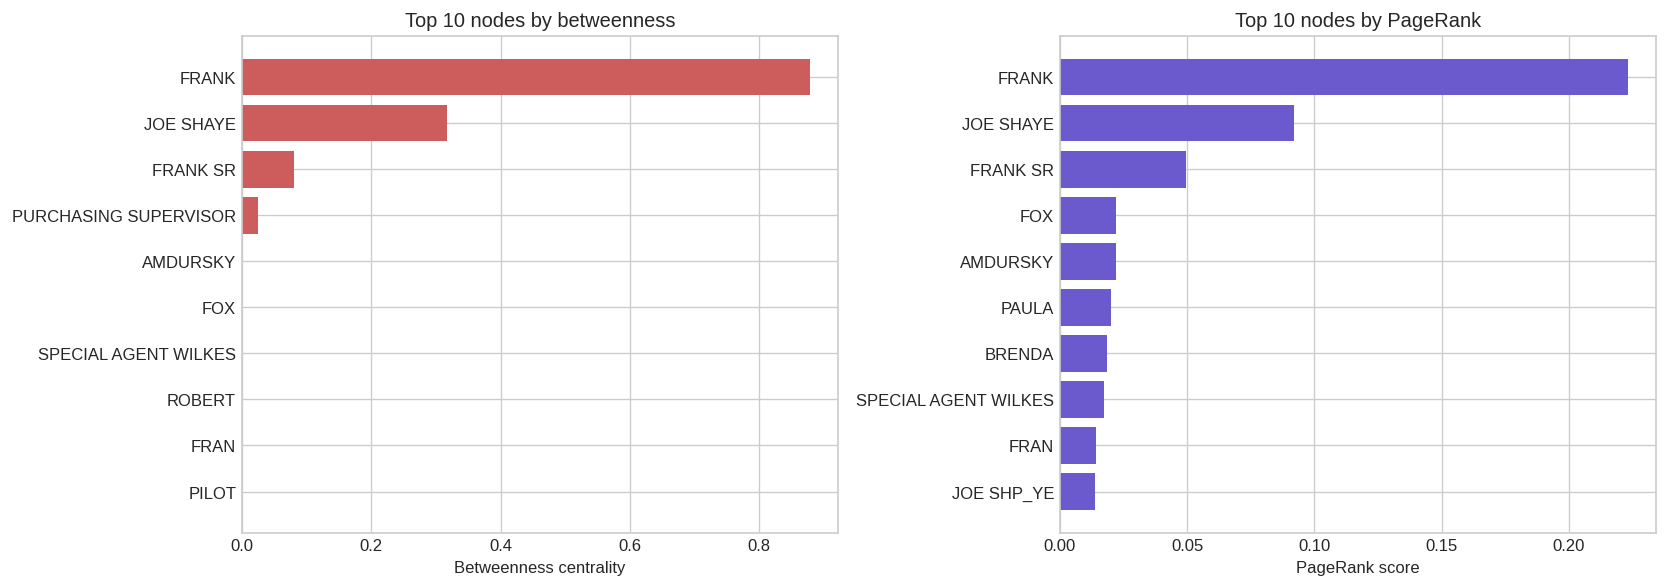

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bet_top = centrality_df.sort_values('betweenness', ascending=False).head(10)
axes[0].barh(bet_top['label'][::-1], bet_top['betweenness'][::-1], color='indianred')
axes[0].set_title('Top 10 nodes by betweenness')
axes[0].set_xlabel('Betweenness centrality')

pr_top = centrality_df.sort_values('pagerank', ascending=False).head(10)
axes[1].barh(pr_top['label'][::-1], pr_top['pagerank'][::-1], color='slateblue')
axes[1].set_title('Top 10 nodes by PageRank')
axes[1].set_xlabel('PageRank score')

plt.tight_layout()
plt.show()

In [15]:
# identify the most central nodes according to each measure
most_central_betweenness = centrality_df.sort_values('betweenness', ascending=False).iloc[0]
most_central_pagerank = centrality_df.sort_values('pagerank', ascending=False).iloc[0]

print(
    f"Highest betweenness: {most_central_betweenness['label']} "
    f"(node {int(most_central_betweenness['node'])}, score = {most_central_betweenness['betweenness']:.4f})"
)
print(
    f"Highest PageRank: {most_central_pagerank['label']} "
    f"(node {int(most_central_pagerank['node'])}, score = {most_central_pagerank['pagerank']:.4f})"
)

Highest betweenness: FRANK (node 22, score = 0.8780)
Highest PageRank: FRANK (node 22, score = 0.2231)


### Comment

The results show that **Frank Abagnale Jr.** is the most central character according to both measures. His **highest betweenness centrality** (0.878) means most shortest paths between other characters pass through him, reflecting his role as the main connector. He also has the **highest PageRank** (0.223), indicating a globally dominant position. The comparison with NetworkX’s built-in PageRank confirms the manual implementation is correct. **Joe Shaye** and **Frank Sr.** also rank highly, reinforcing the interpretation that Frank is the structural center of the movie’s character network.

## Week 6

In this part, we study community structure after transforming the graph into an **undirected and unweighted** network, removing self-loops, and restricting attention to the **largest connected component**. We compare **bridge removal (Girvan–Newman)** and **modularity optimization**, then select the partition with the higher modularity and visualize it in ***Gephi.***

In [16]:
# build an undirected, unweighted version of the graph
G_week6 = nx.Graph()
G_week6.add_nodes_from(G.nodes(data=True))
G_week6.add_edges_from((u, v) for u, v in G.edges() if u != v)

# work on the largest connected component
if nx.is_connected(G_week6):
    G_week6_lcc = G_week6.copy()
else:
    week6_component_nodes = max(nx.connected_components(G_week6), key=len)
    G_week6_lcc = G_week6.subgraph(week6_component_nodes).copy()

print(
    f"Week 6 graph: {G_week6_lcc.number_of_nodes()} nodes, "
    f"{G_week6_lcc.number_of_edges()} edges"
)

Week 6 graph: 82 nodes, 162 edges


In [17]:
import time

# run Girvan–Newman and keep the partition with highest modularity
def best_girvan_newman_partition(graph):

    start = time.perf_counter()

    best_partition = None
    best_modularity = float("-inf")
    modularity_trace = []

    for partition in nx.community.girvan_newman(graph):
        partition = tuple(frozenset(comm) for comm in partition)

        mod = nx.community.modularity(graph, partition)
        modularity_trace.append((len(partition), mod))

        if mod > best_modularity:
            best_modularity = mod
            best_partition = partition

        if len(partition) >= graph.number_of_nodes():
            break

    elapsed = time.perf_counter() - start
    return best_partition, best_modularity, modularity_trace, elapsed


# Girvan–Newman (bridge removal)
gn_partition, gn_modularity, gn_trace, gn_time = best_girvan_newman_partition(G_week6_lcc)


# greedy modularity optimization
start = time.perf_counter()
greedy_partition = list(nx.community.greedy_modularity_communities(G_week6_lcc))
greedy_modularity = nx.community.modularity(G_week6_lcc, greedy_partition)
greedy_time = time.perf_counter() - start


# comparison between the two methods
community_comparison = pd.DataFrame({
    "method": [
        "Bridge removal (Girvan–Newman)",
        "Modularity optimization (Greedy)"
    ],
    "num_communities": [len(gn_partition), len(greedy_partition)],
    "modularity": [gn_modularity, greedy_modularity],
    "time_seconds": [gn_time, greedy_time],
    "community_sizes": [
        sorted([len(c) for c in gn_partition], reverse=True),
        sorted([len(c) for c in greedy_partition], reverse=True),
    ],
})

community_comparison

,method,num_communities,modularity,time_seconds,community_sizes
0,Bridge removal (Girvan–Newman),8,0.414018,0.926843,"[32, 20, 10, 7, 4, 3, 3, 3]"
1,Modularity optimization (Greedy),7,0.431584,0.026892,"[30, 19, 17, 7, 3, 3, 3]"


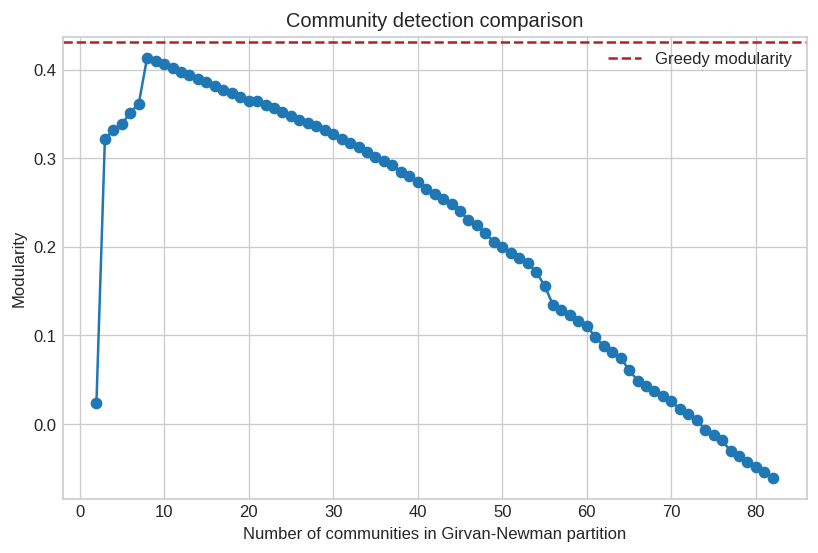

In [18]:
gn_trace_df = pd.DataFrame(gn_trace, columns=['num_communities', 'modularity'])

plt.figure(figsize=(8, 5))
plt.plot(gn_trace_df['num_communities'], gn_trace_df['modularity'], marker='o')
plt.axhline(greedy_modularity, color='firebrick', linestyle='--', label='Greedy modularity')
plt.xlabel('Number of communities in Girvan-Newman partition')
plt.ylabel('Modularity')
plt.title('Community detection comparison')
plt.legend()
plt.show()

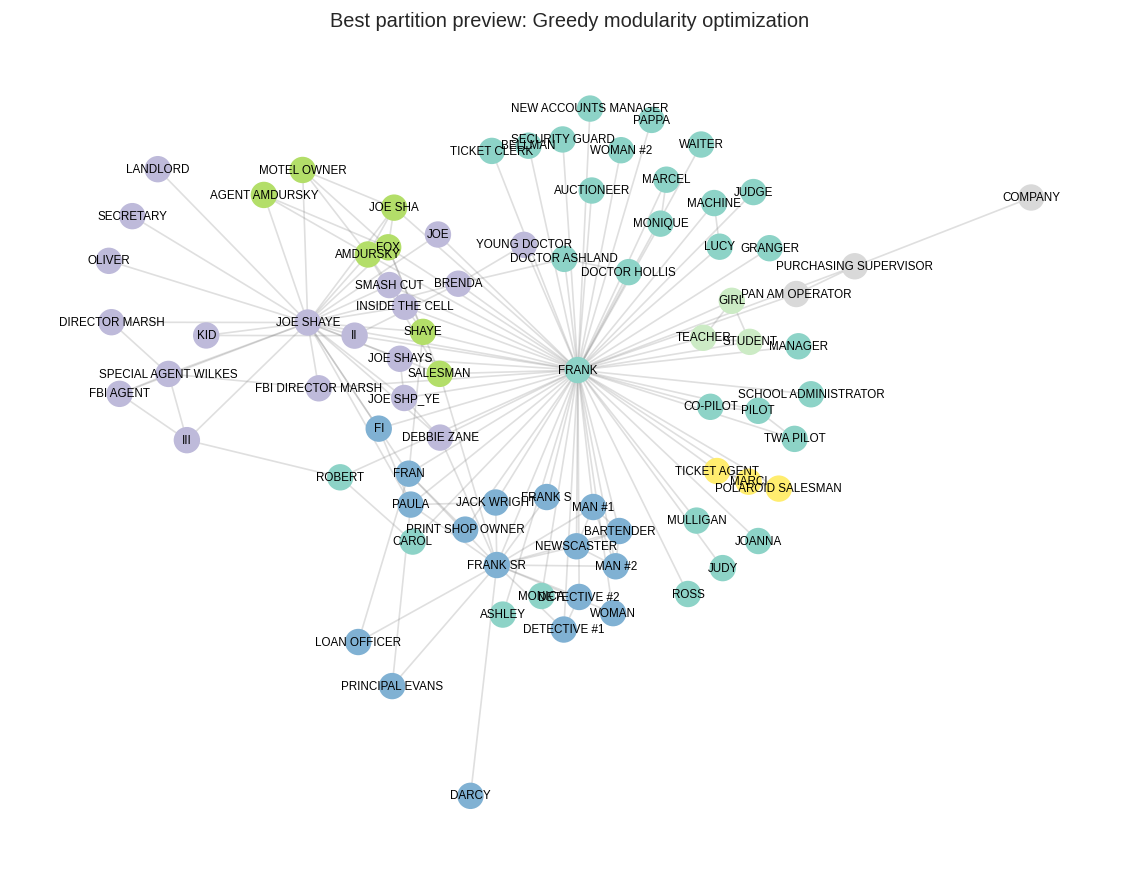

In [19]:
# select the partition with the highest modularity
if greedy_modularity >= gn_modularity:
    best_partition_name = 'Greedy modularity optimization'
    best_partition = greedy_partition
else:
    best_partition_name = 'Girvan-Newman'
    best_partition = gn_partition

# map each node to its community
partition_map = {}
for community_id, community_nodes in enumerate(best_partition):
    for node in community_nodes:
        partition_map[node] = community_id

# preview visualization of detected communities
preview_layout = nx.spring_layout(G_week6_lcc, seed=42)
node_colors = [partition_map[node] for node in G_week6_lcc.nodes()]

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G_week6_lcc, pos=preview_layout, alpha=0.25, edge_color='gray')
nx.draw_networkx_nodes(
    G_week6_lcc,
    pos=preview_layout,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    node_size=220,
)
nx.draw_networkx_labels(
    G_week6_lcc,
    pos=preview_layout,
    labels={node: G_week6_lcc.nodes[node]['label'] for node in G_week6_lcc.nodes()},
    font_size=7,
)
plt.title(f'Best partition preview: {best_partition_name}')
plt.axis('off')
plt.show()

In [20]:
print(f'Best method: {best_partition_name}')
print('Community preview plotted successfully.')

Best method: Greedy modularity optimization
Community preview plotted successfully.


In [21]:
# Save the selected partition as a node attribute for Gephi
nx.set_node_attributes(G_week6_lcc, partition_map, "community")

# Export the graph for Gephi
nx.write_gexf(G_week6_lcc, "catch_me_if_you_can_week6.gexf")

print("GEXF file exported successfully.")

GEXF file exported successfully.


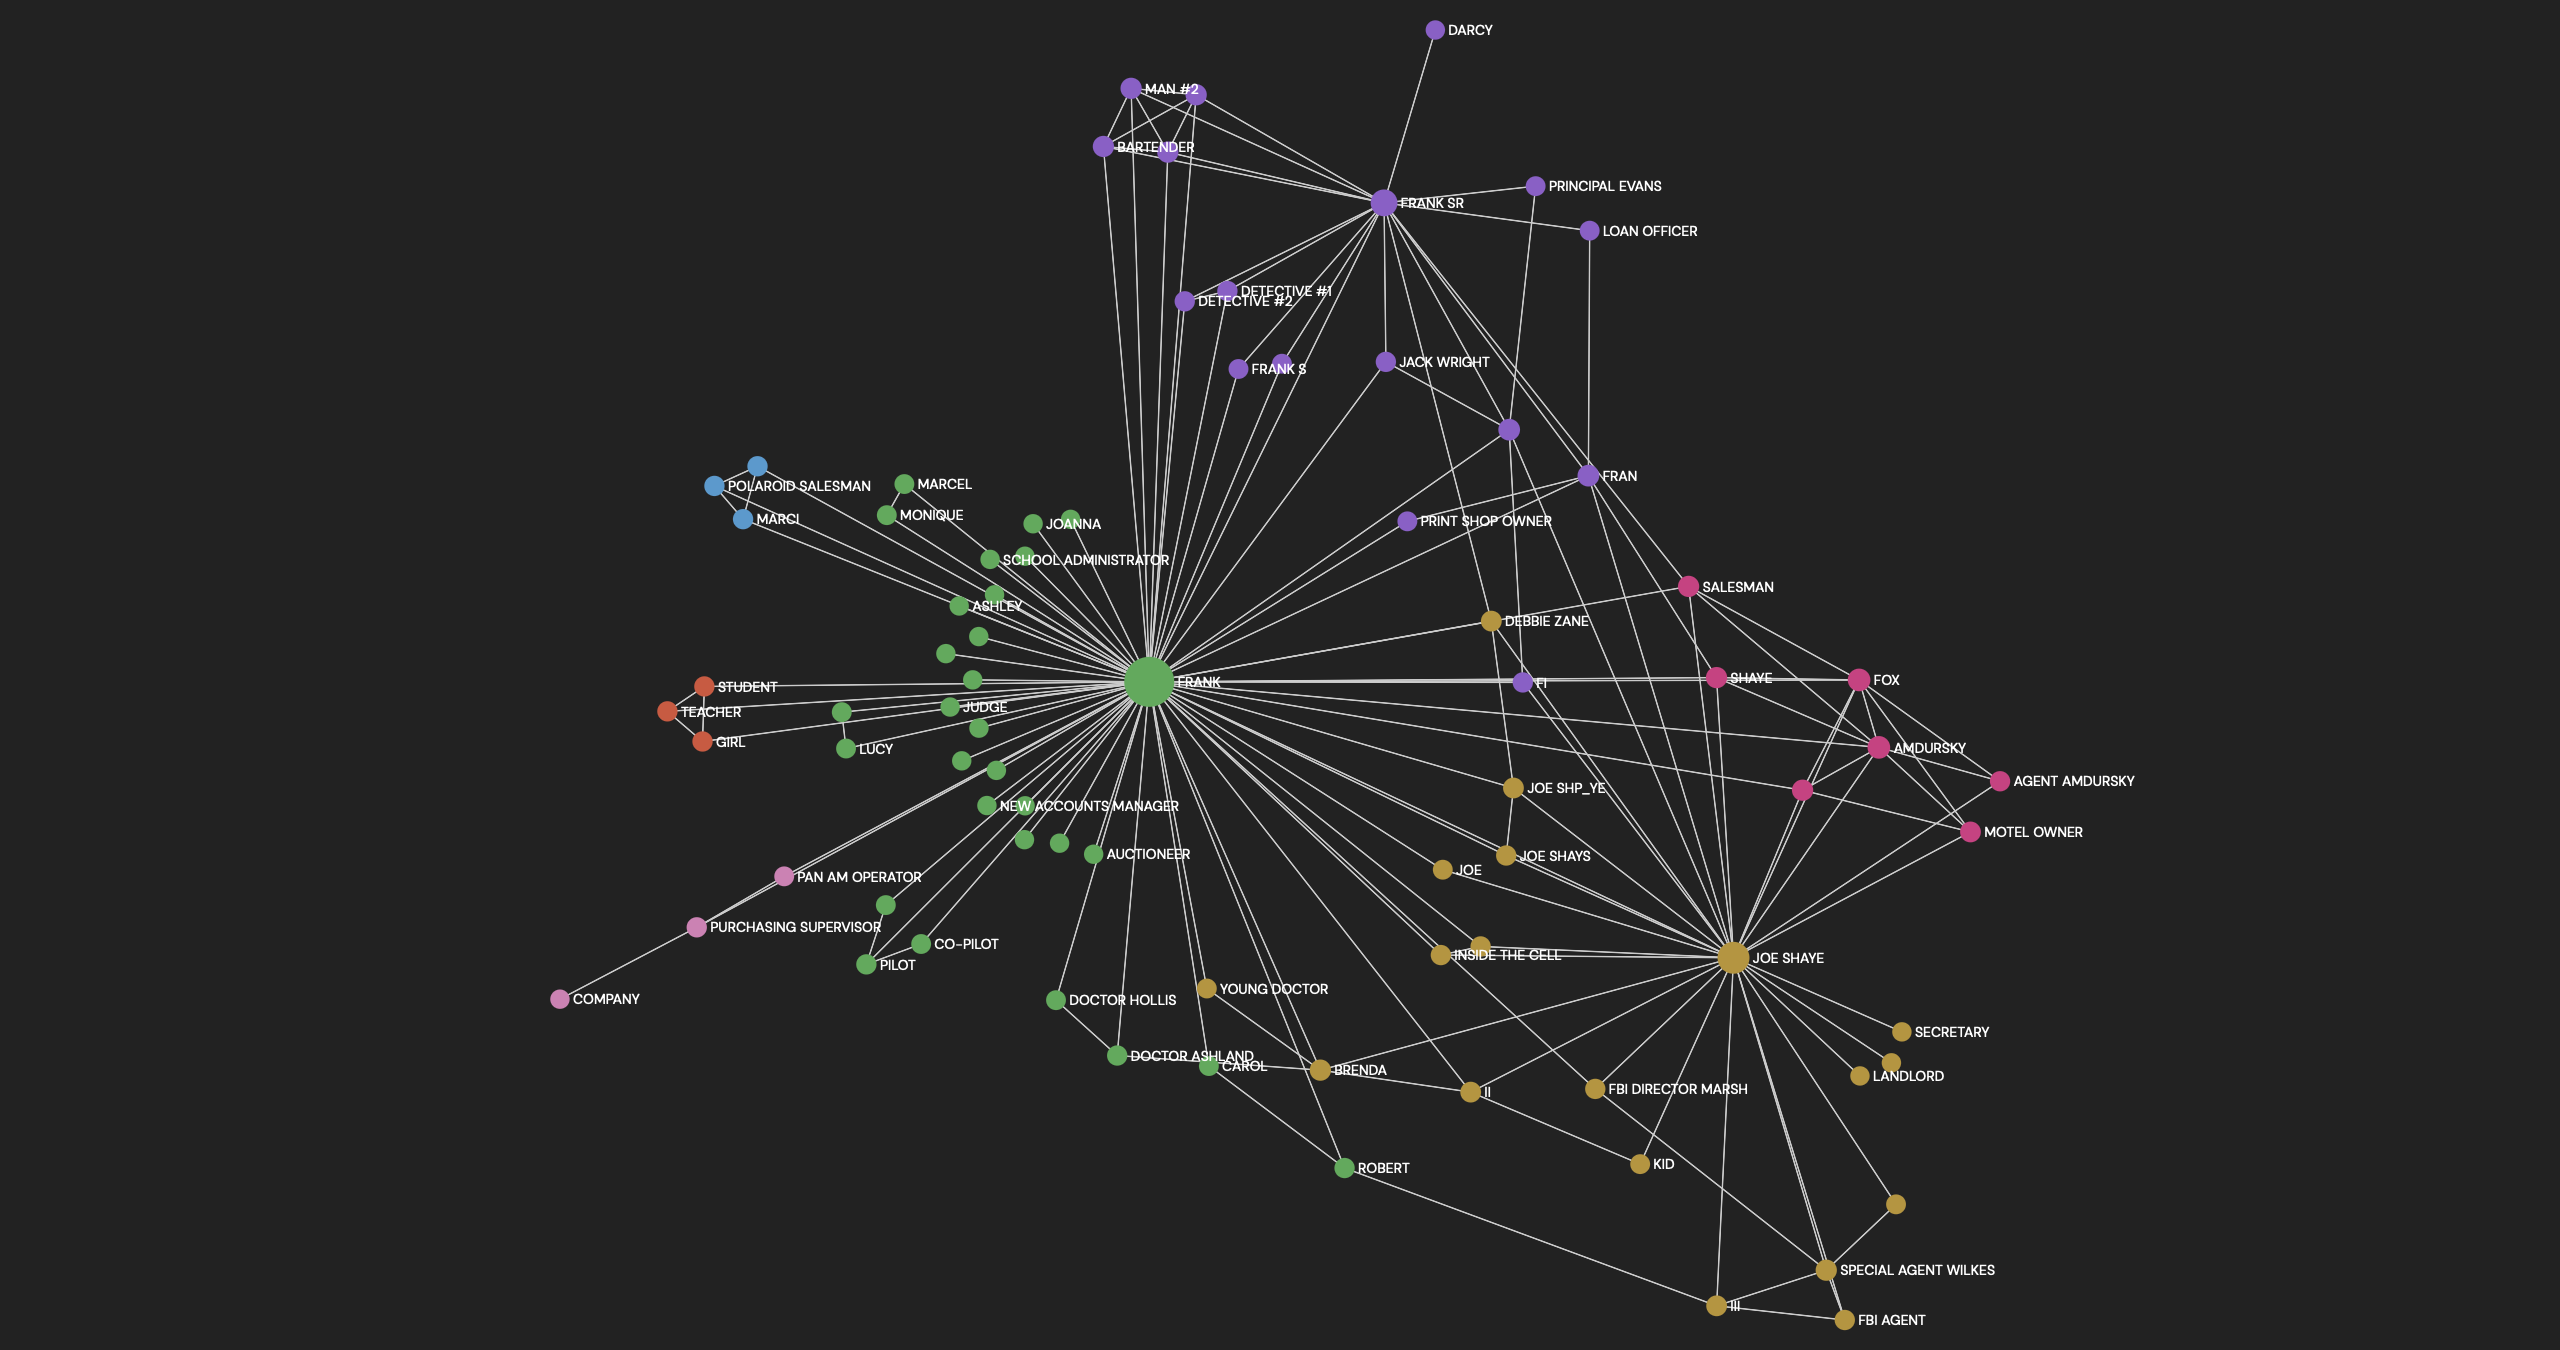

In [22]:
from IPython.display import Image
Image("week6_gephi_visualization.png")

### Comment

The comparison shows that **modularity optimization** performs slightly better than **bridge removal**, with a modularity of about **0.432** compared with **0.414.** This suggests a partition with stronger within-community cohesion and weaker between-community connectivity. In addition, modularity optimization is much faster, which makes it more practical for this network. For these reasons, it is selected as the best method. The **Gephi visualization** helps make the detected communities more readable by separating groups spatially and coloring nodes according to their assigned community. The figure highlights a clear hub structure centered on **Frank**, while also showing distinct groups of secondary characters organized around different parts of the story.


## Week 7

We perform **link prediction** on the undirected, unweighted largest connected component. For every pair of unconnected nodes (a *missing link*) we compute two scores: **Common Neighbors (CN)** and **Adamic-Adar (AA)**. A third combined score is the arithmetic mean of both indices after rescaling each to [0, 1]. The top 10 candidates are reported for each score.

In [23]:
# build unweighted, undirected graph without self-loops
G_w7 = nx.Graph()
G_w7.add_nodes_from(G.nodes(data=True))
G_w7.add_edges_from((u, v) for u, v in G.edges() if u != v)

# largest connected component
if nx.is_connected(G_w7):
    G_w7_lcc = G_w7.copy()
else:
    w7_nodes = max(nx.connected_components(G_w7), key=len)
    G_w7_lcc = G_w7.subgraph(w7_nodes).copy()

print(f"Week 7 graph: {G_w7_lcc.number_of_nodes()} nodes, {G_w7_lcc.number_of_edges()} edges")

Week 7 graph: 82 nodes, 162 edges


In [35]:
def link_prediction_scores(graph):
    nodes = list(graph.nodes())

    # all non-connected pairs (missing links)
    missing_links = [
        (u, v) for u, v in combinations(nodes, 2)
        if not graph.has_edge(u, v)
    ]

    # Common Neighbors
    cn = {
        (u, v): len(list(nx.common_neighbors(graph, u, v)))
        for u, v in missing_links
    }

    # Adamic-Adar index (built-in NetworkX)
    aa = {
        (u, v): score
        for u, v, score in nx.adamic_adar_index(graph, missing_links)
    }

    df = pd.DataFrame({
        'node_u':  [u for u, v in missing_links],
        'node_v':  [v for u, v in missing_links],
        'label_u': [graph.nodes[u]['label'] for u, v in missing_links],
        'label_v': [graph.nodes[v]['label'] for u, v in missing_links],
        'CN':      [cn[(u, v)]  for u, v in missing_links],
        'AA':      [aa[(u, v)]  for u, v in missing_links],
    })

    # rescale each index to [0, 1]
    df['CN_scaled'] = (df['CN'] - df['CN'].min()) / (df['CN'].max() - df['CN'].min())
    df['AA_scaled'] = (df['AA'] - df['AA'].min()) / (df['AA'].max() - df['AA'].min())

    # combined score: arithmetic mean of the two rescaled indices
    df['combined'] = (df['CN_scaled'] + df['AA_scaled']) / 2

    return df[['node_u', 'node_v', 'label_u', 'label_v', 'CN', 'AA', 'combined']]


scores_df = link_prediction_scores(G_w7_lcc)
print(f"Total missing links evaluated: {len(scores_df)}")
scores_df.head(10)

Total missing links evaluated: 3159


,node_u,node_v,label_u,label_v,CN,AA,combined
0,0,2,AGENT AMDURSKY,ASHLEY,0,0.000000,0.000000
1,0,3,AGENT AMDURSKY,AUCTIONEER,0,0.000000,0.000000
2,0,4,AGENT AMDURSKY,BARTENDER,0,0.000000,0.000000
3,0,5,AGENT AMDURSKY,BELLMAN,0,0.000000,0.000000
4,0,6,AGENT AMDURSKY,BRENDA,1,0.300102,0.155642
5,0,7,AGENT AMDURSKY,CAROL,0,0.000000,0.000000
6,0,8,AGENT AMDURSKY,CO-PILOT,0,0.000000,0.000000
7,0,9,AGENT AMDURSKY,COMPANY,0,0.000000,0.000000
8,0,10,AGENT AMDURSKY,DARCY,0,0.000000,0.000000
9,0,11,AGENT AMDURSKY,DEBBIE ZANE,1,0.300102,0.155642


In [25]:
TOP_N = 10

print("Top 10 by CN (Common Neighbors)")
top_cn = scores_df.nlargest(TOP_N, 'CN')[['label_u', 'label_v', 'CN']].reset_index(drop=True)
display(top_cn)

print("\nTop 10 by AA (Adamic-Adar)")
top_aa = scores_df.nlargest(TOP_N, 'AA')[['label_u', 'label_v', 'AA']].reset_index(drop=True)
display(top_aa)

print("\nTop 10 by Combined Score (mean of rescaled CN and AA)")
top_combined = scores_df.nlargest(TOP_N, 'combined')[['label_u', 'label_v', 'CN', 'AA', 'combined']].reset_index(drop=True)
display(top_combined)

Top 10 by CN (Common Neighbors)


,label_u,label_v,CN
0,FRANK SR,JOE SHAYE,5
1,FRANK,MOTEL OWNER,4
2,JOE SHA,SALESMAN,4
3,JOE SHA,SHAYE,4
4,SALESMAN,SHAYE,4
5,AGENT AMDURSKY,FRANK,3
6,AGENT AMDURSKY,JOE SHA,3
7,AGENT AMDURSKY,MOTEL OWNER,3
8,AGENT AMDURSKY,SALESMAN,3
9,AGENT AMDURSKY,SHAYE,3



Top 10 by AA (Adamic-Adar)


,label_u,label_v,AA
0,FRANK SR,JOE SHAYE,2.696733
1,FRANK,MOTEL OWNER,1.883233
2,JOE SHA,SALESMAN,1.499728
3,JOE SHA,SHAYE,1.499728
4,SALESMAN,SHAYE,1.499728
5,AGENT AMDURSKY,FRANK,1.261898
6,AGENT AMDURSKY,JOE SHA,1.261898
7,AGENT AMDURSKY,MOTEL OWNER,1.261898
8,AGENT AMDURSKY,SALESMAN,1.261898
9,AGENT AMDURSKY,SHAYE,1.261898



Top 10 by Combined Score (mean of rescaled CN and AA)


,label_u,label_v,CN,AA,combined
0,FRANK SR,JOE SHAYE,5,2.696733,1.000000
1,FRANK,MOTEL OWNER,4,1.883233,0.749169
2,JOE SHA,SALESMAN,4,1.499728,0.678064
3,JOE SHA,SHAYE,4,1.499728,0.678064
4,SALESMAN,SHAYE,4,1.499728,0.678064
5,AGENT AMDURSKY,FRANK,3,1.261898,0.533968
6,AGENT AMDURSKY,JOE SHA,3,1.261898,0.533968
7,AGENT AMDURSKY,MOTEL OWNER,3,1.261898,0.533968
8,AGENT AMDURSKY,SALESMAN,3,1.261898,0.533968
9,AGENT AMDURSKY,SHAYE,3,1.261898,0.533968


### Comment

The three scores produce a consistent ranking, all placing **FRANK SR and JOE SHAYE** at the top with **5 common neighbors** and an Adamic-Adar score of **2.697**. The second-strongest is **FRANK and MOTEL OWNER** (CN = 4), followed by three pairs involving JOE SHA, SALESMAN, and SHAYE, which share 4 common neighbors and identical AA scores. CN and AA yield the same ordering throughout, suggesting the penalization of high-degree shared neighbors in AA does not alter the ranking here. Most predicted missing links cluster around FRANK, reflecting his hub position: characters already connected to him accumulate many common neighbors, making them natural candidates for unobserved co-scene appearances.

## Week 9

We propose a **Preferential Attachment with Triad Closure (PA+TC)** graph as our invented variant. Plain preferential attachment is a natural starting point given FRANK's hub dominance, but it produces very low clustering compared to the original **0.599**. PA+TC adds a probability **p** that each new node's second edge closes a triangle instead. **m = 2** is derived analytically: since average degree ≈ 2m, matching the original **3.95** requires m ≈ 2. We calibrate p via a parameter sweep and compare the variant on degree, clustering, transitivity, and degree distribution.

In [26]:
def pa_triad_closure_graph(n, m, p, seed=None):

    rng = random.Random(seed)
    G_model = nx.complete_graph(m + 1) # initial clique

    for new_node in range(m + 1, n):
        G_model.add_node(new_node)
        chosen = []

        for edge_idx in range(m):
            # attempt triad closure on all edges after the first
            if edge_idx > 0 and rng.random() < p and chosen:
                anchor = rng.choice(chosen)
                candidates = [
                    nb for nb in G_model.neighbors(anchor)
                    if nb != new_node
                    and nb not in chosen
                    and not G_model.has_edge(new_node, nb)
                ]
                if candidates:
                    target = rng.choice(candidates)
                    chosen.append(target)
                    G_model.add_edge(new_node, target)
                    continue

            # standard preferential attachment
            pool = [v for v in G_model.nodes() if v != new_node and v not in chosen]
            if not pool:
                break
            degrees = [G_model.degree(v) for v in pool]
            total   = sum(degrees)
            if total == 0:
                target = rng.choice(pool)
            else:
                r, cumsum = rng.random() * total, 0
                target = pool[-1]
                for v, d in zip(pool, degrees):
                    cumsum += d
                    if cumsum >= r:
                        target = v
                        break
            chosen.append(target)
            G_model.add_edge(new_node, target)

    return G_model

Original avg clustering : 0.5991
Best p (closest match)  : 0.80


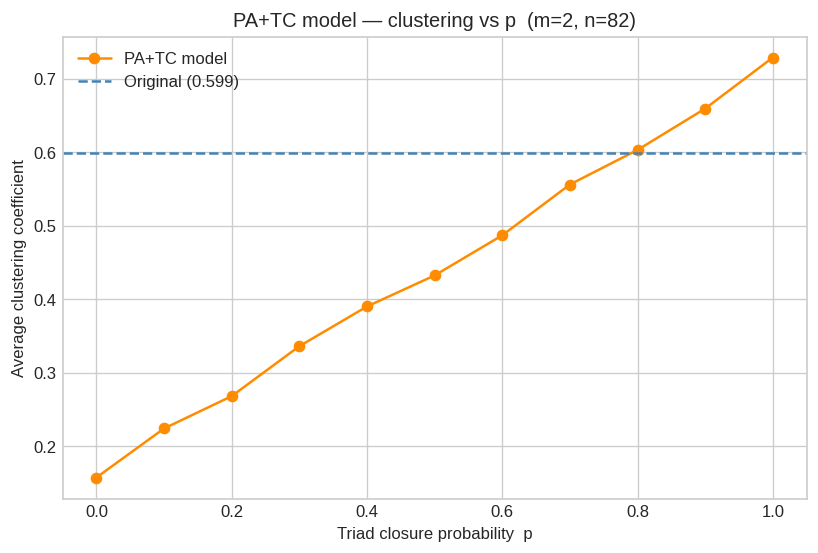

In [27]:
from collections import Counter

n_target = G.number_of_nodes()
m_pa     = 2
N_SIM    = 50
N_SWEEP  = 20

p_values       = np.linspace(0, 1, 11)
orig_clustering = nx.average_clustering(G)
mean_clusterings = []

for p_val in p_values:
    clust = [nx.average_clustering(pa_triad_closure_graph(n_target, m_pa, p_val, seed=s))
             for s in range(N_SWEEP)]
    mean_clusterings.append(np.mean(clust))

# choose p closest to original average clustering
best_p = float(p_values[np.argmin(np.abs(np.array(mean_clusterings) - orig_clustering))])
print(f"Original avg clustering : {orig_clustering:.4f}")
print(f"Best p (closest match)  : {best_p:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(p_values, mean_clusterings, marker='o', color='darkorange', label='PA+TC model')
plt.axhline(orig_clustering, color='steelblue', linestyle='--', label=f'Original ({orig_clustering:.3f})')
plt.xlabel('Triad closure probability  p')
plt.ylabel('Average clustering coefficient')
plt.title('PA+TC model — clustering vs p  (m=2, n=82)')
plt.legend()
plt.show()

In [28]:
stats = {'avg_degree': [], 'avg_clustering': [], 'transitivity': []}

for seed in range(N_SIM):
    g = pa_triad_closure_graph(n_target, m_pa, best_p, seed=seed)
    stats['avg_degree'].append(2 * g.number_of_edges() / g.number_of_nodes())
    stats['avg_clustering'].append(nx.average_clustering(g))
    stats['transitivity'].append(nx.transitivity(g))

comparison_w9 = pd.DataFrame({
    'Metric': ['Average degree', 'Average clustering', 'Transitivity'],
    'Original network': [
        round(2 * G.number_of_edges() / G.number_of_nodes(), 4),
        round(nx.average_clustering(G), 4),
        round(nx.transitivity(G), 4),
    ],
    f'PA+TC (mean, {N_SIM} runs)': [
        round(np.mean(stats['avg_degree']), 4),
        round(np.mean(stats['avg_clustering']), 4),
        round(np.mean(stats['transitivity']), 4),
    ],
    f'PA+TC (std, {N_SIM} runs)': [
        round(np.std(stats['avg_degree']), 4),
        round(np.std(stats['avg_clustering']), 4),
        round(np.std(stats['transitivity']), 4),
    ],
})

comparison_w9

,Metric,Original network,"PA+TC (mean, 50 runs)","PA+TC (std, 50 runs)"
0,Average degree,3.9512,3.9268,0.0000
1,Average clustering,0.5991,0.6116,0.0410
2,Transitivity,0.1147,0.2006,0.0184


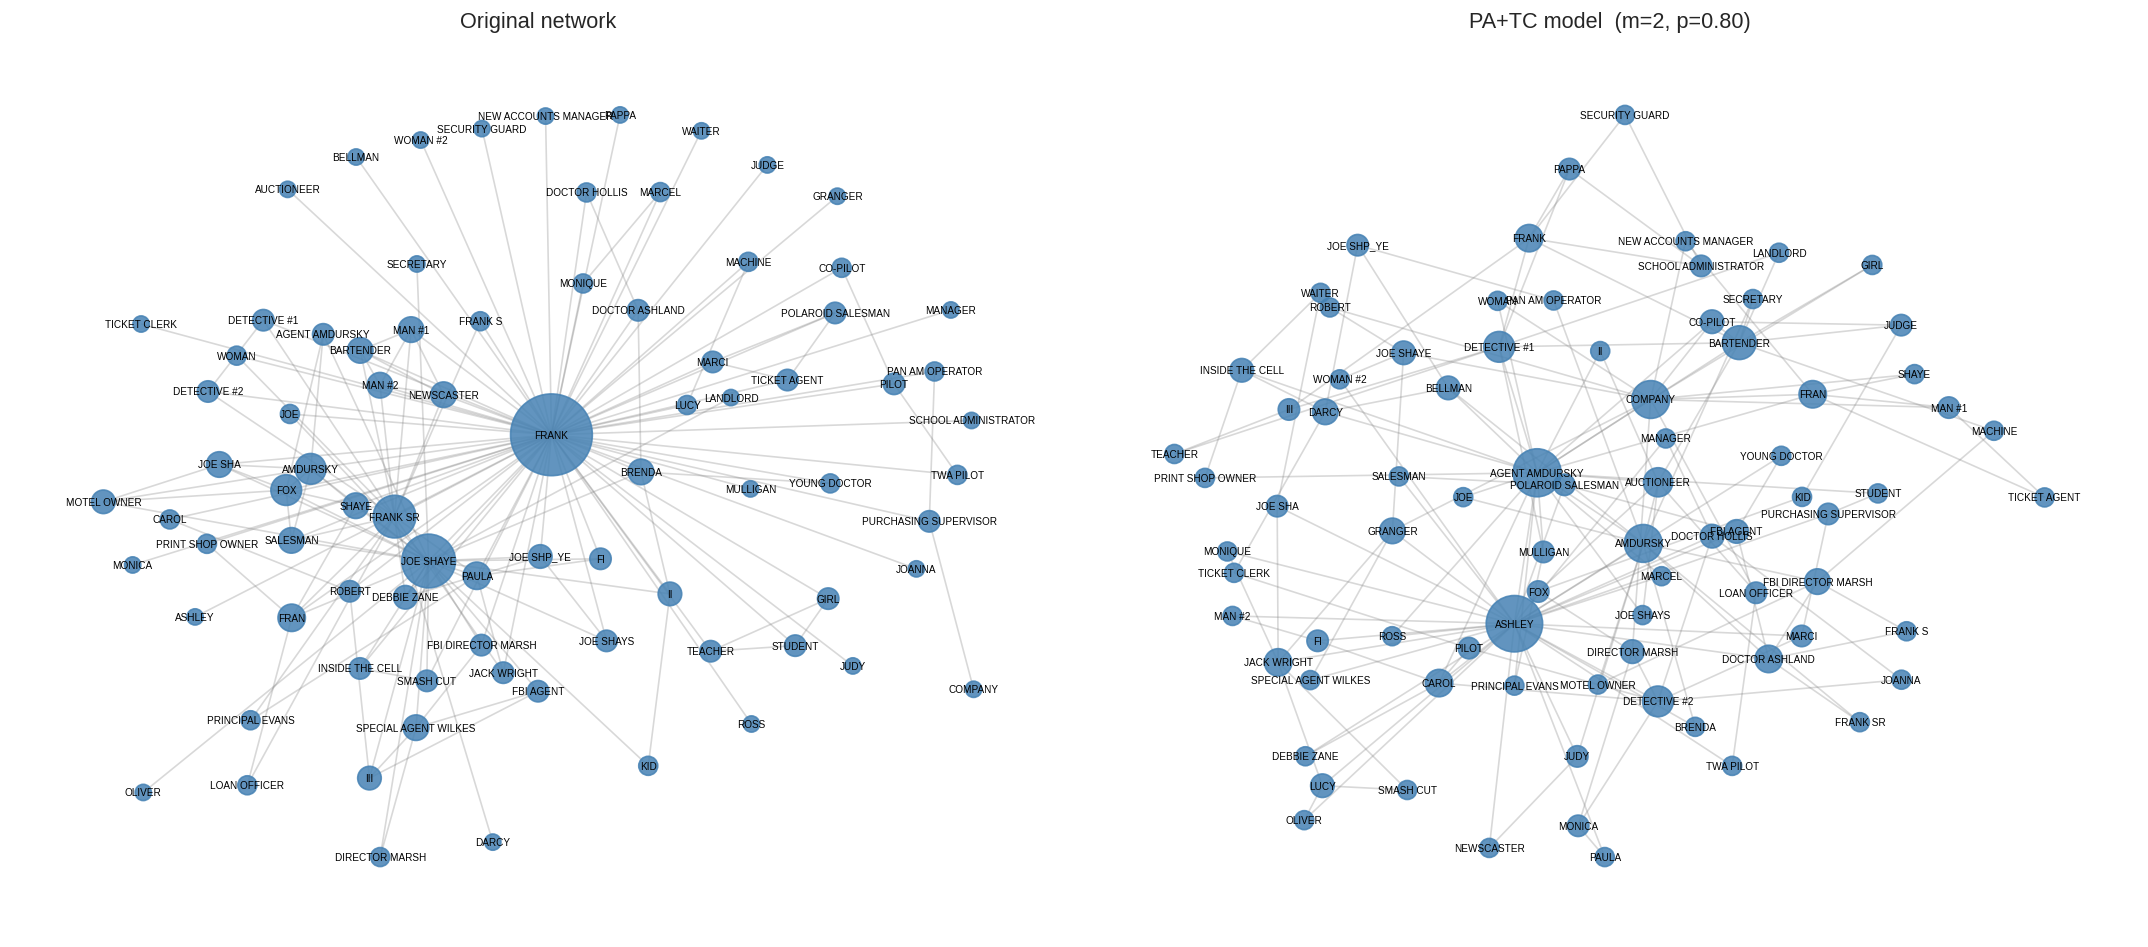

In [29]:
sample_variant = pa_triad_closure_graph(n_target, m_pa, best_p, seed=42)

# copy character labels from the original graph so both panels show names
for node in sample_variant.nodes():
    if node in G.nodes():
        sample_variant.nodes[node]['label'] = G.nodes[node]['label']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, graph, title in zip(
    axes,
    [G, sample_variant],
    ['Original network', f'PA+TC model  (m={m_pa}, p={best_p:.2f})'],
):
    pos   = nx.spring_layout(graph, seed=42, k=0.5)
    sizes = [60 + 35 * graph.degree(n) for n in graph.nodes()]
    nx.draw_networkx_edges(graph, pos=pos, ax=ax, alpha=0.3, edge_color='gray')
    nx.draw_networkx_nodes(graph, pos=pos, ax=ax, node_size=sizes,
                           node_color='steelblue', alpha=0.85)
    nx.draw_networkx_labels(
        graph, pos=pos, ax=ax, font_size=6,
        labels={n: data['label'] for n, data in graph.nodes(data=True)},
    )
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

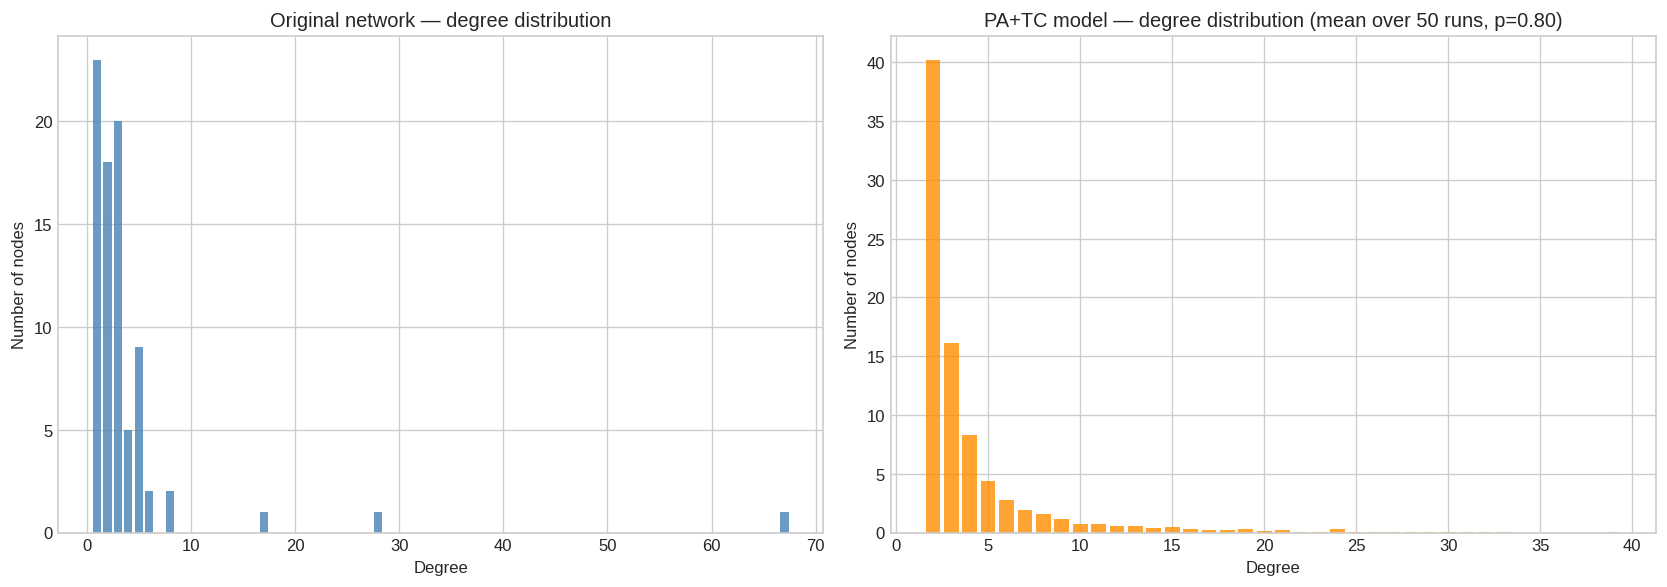

In [30]:
variant_counters = [
    Counter(d for _, d in pa_triad_closure_graph(n_target, m_pa, best_p, seed=s).degree())
    for s in range(N_SIM)
]
all_degs  = sorted(set(k for c in variant_counters for k in c))
avg_freq  = {d: np.mean([c.get(d, 0) for c in variant_counters]) for d in all_degs}
orig_ctr  = Counter(d for _, d in G.degree())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(orig_ctr.keys(), orig_ctr.values(), color='steelblue', alpha=0.8)
axes[0].set_title('Original network — degree distribution')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Number of nodes')

axes[1].bar(all_degs, [avg_freq[d] for d in all_degs], color='darkorange', alpha=0.8)
axes[1].set_title(f'PA+TC model — degree distribution (mean over {N_SIM} runs, p={best_p:.2f})')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Number of nodes')

plt.tight_layout()
plt.show()

### Comment

The parameter sweep identified **p = 0.80** as the best match for average clustering. The model closely reproduces both the average degree (**3.927 vs 3.951**) and the average clustering (**0.612 vs 0.599**), which was the main property that motivated the triad closure extension over plain preferential attachment. Transitivity is overestimated (**0.201 vs 0.115**), suggesting the triad closure mechanism creates more globally connected triangles than the movie network actually contains. This gap likely reflects the fact that in the original graph, triangle formation is more selective. The degree distributions have a similar right-skewed shape in both graphs, consistent with the presence of a dominant hub.

## Week 10

We simulate an **SIR (Susceptible–Infected–Recovered)** contagion model on the network, representing how rumours about Frank's schemes spread through the cast: characters turn **Infected** upon contact with infected scene partners at rate **β**, and recover at rate **μ**. Three families of scenarios are investigated: different origins, different parameter values for β and μ, and different initial outbreak sizes.

In [31]:
def simulation_SIR(G, I, T, beta, mu):

    state = {node: 'S' for node in G.nodes()}
    for node in I:
        state[node] = 'I'

    s = sum(1 for v in state.values() if v == 'S')
    i = sum(1 for v in state.values() if v == 'I')
    r = 0
    data_S, data_I, data_R = [s], [i], [r]

    t = 0
    while t < T and i > 0:
        t += 1
        for node in G.nodes():
            if state[node] == 'I' and random.random() <= mu:
                state[node] = 'R'
                i -= 1
                r += 1
            elif state[node] == 'S':
                for neighbor in G.neighbors(node):
                    if state[neighbor] == 'I' and random.random() <= beta:
                        state[node] = 'I'
                        s -= 1
                        i += 1
                        break
        data_S.append(s)
        data_I.append(i)
        data_R.append(r)

    return list(range(t + 1)), data_S, data_I, data_R


def avg_final_recovered(G, I, T, beta, mu, n_runs=50):
    """Average number of recovered nodes at end of epidemic over n_runs simulations."""
    return np.mean([
        simulation_SIR(G, I, T, beta, mu)[3][-1]
        for _ in range(n_runs)
    ])

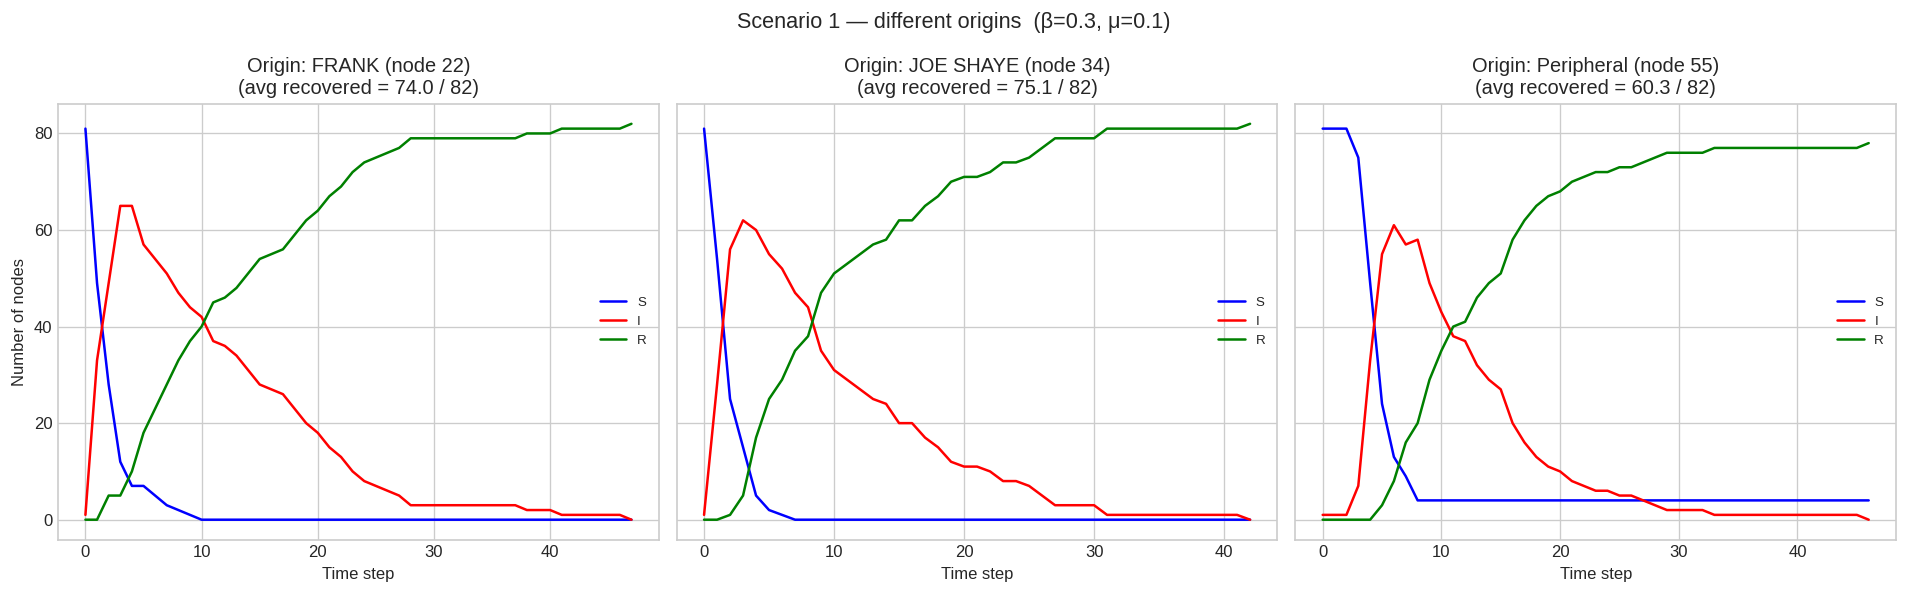

In [32]:
random.seed(42)
T, beta, mu = 60, 0.3, 0.1
N_RUNS = 50

# pick a high-centrality, mid-centrality, and peripheral starting node
frank_node   = int(centrality_df.sort_values('pagerank', ascending=False).iloc[0]['node'])
joe_node     = int(centrality_df.sort_values('pagerank', ascending=False).iloc[1]['node'])
peripheral_node = int(centrality_df.sort_values('pagerank').iloc[0]['node'])

origins = {
    f'FRANK (node {frank_node})':        [frank_node],
    f'JOE SHAYE (node {joe_node})':      [joe_node],
    f'Peripheral (node {peripheral_node})': [peripheral_node],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (label, seed) in zip(axes, origins.items()):
    data_x, data_S, data_I, data_R = simulation_SIR(G, seed, T, beta, mu)
    ax.plot(data_x, data_S, 'b', label='S')
    ax.plot(data_x, data_I, 'r', label='I')
    ax.plot(data_x, data_R, 'g', label='R')
    avg_r = avg_final_recovered(G, seed, T, beta, mu, N_RUNS)
    ax.set_title(f'Origin: {label}\n(avg recovered = {avg_r:.1f} / {G.number_of_nodes()})')
    ax.set_xlabel('Time step')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Number of nodes')
plt.suptitle(f'Scenario 1 — different origins  (β={beta}, μ={mu})', fontsize=13)
plt.tight_layout()
plt.show()

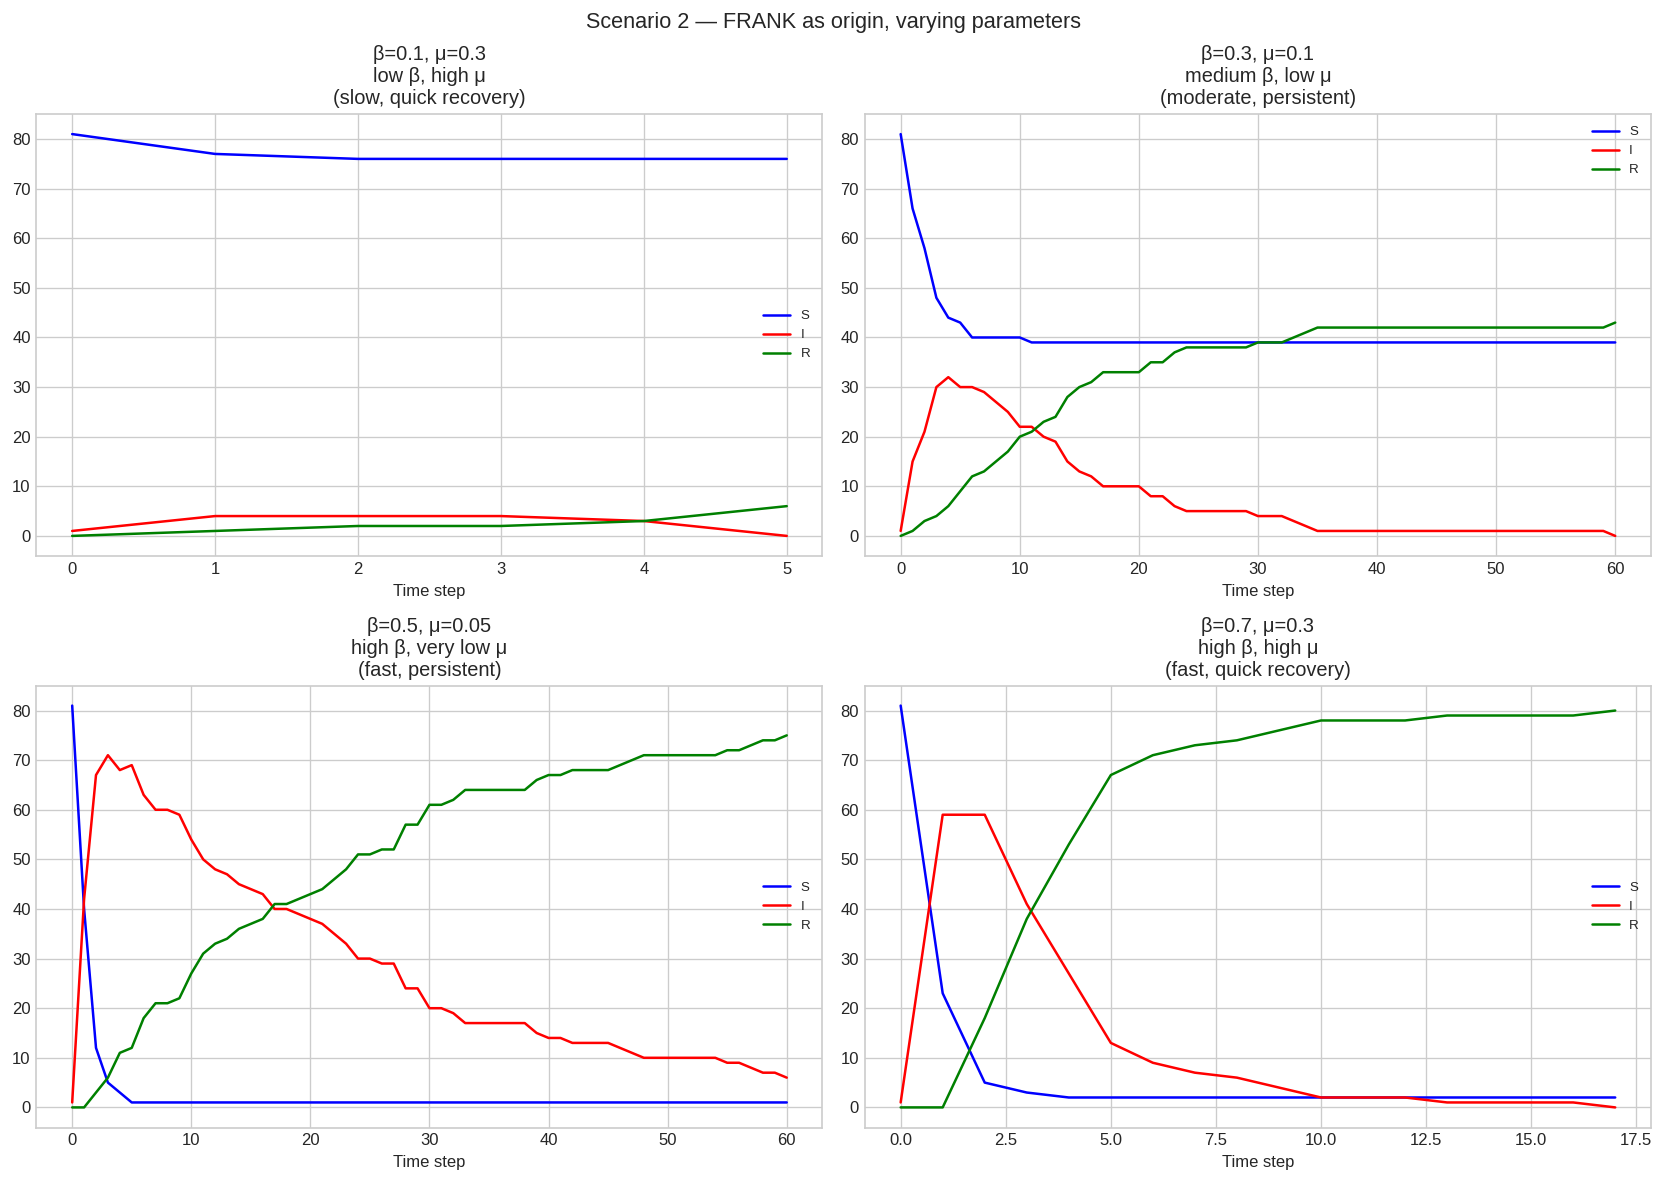

In [33]:
random.seed(42)
# try different combinations of beta and mu, always starting from Frank
T = 60
param_sets = [
    (0.1, 0.3, 'low β, high μ\n(slow, quick recovery)'),
    (0.3, 0.1, 'medium β, low μ\n(moderate, persistent)'),
    (0.5, 0.05, 'high β, very low μ\n(fast, persistent)'),
    (0.7, 0.3,  'high β, high μ\n(fast, quick recovery)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (b, m_, desc) in zip(axes, param_sets):
    data_x, data_S, data_I, data_R = simulation_SIR(G, [frank_node], T, b, m_)
    ax.plot(data_x, data_S, 'b', label='S')
    ax.plot(data_x, data_I, 'r', label='I')
    ax.plot(data_x, data_R, 'g', label='R')
    ax.set_title(f'β={b}, μ={m_}\n{desc}')
    ax.set_xlabel('Time step')
    ax.legend(fontsize=8)

plt.suptitle('Scenario 2 — FRANK as origin, varying parameters', fontsize=13)
plt.tight_layout()
plt.show()

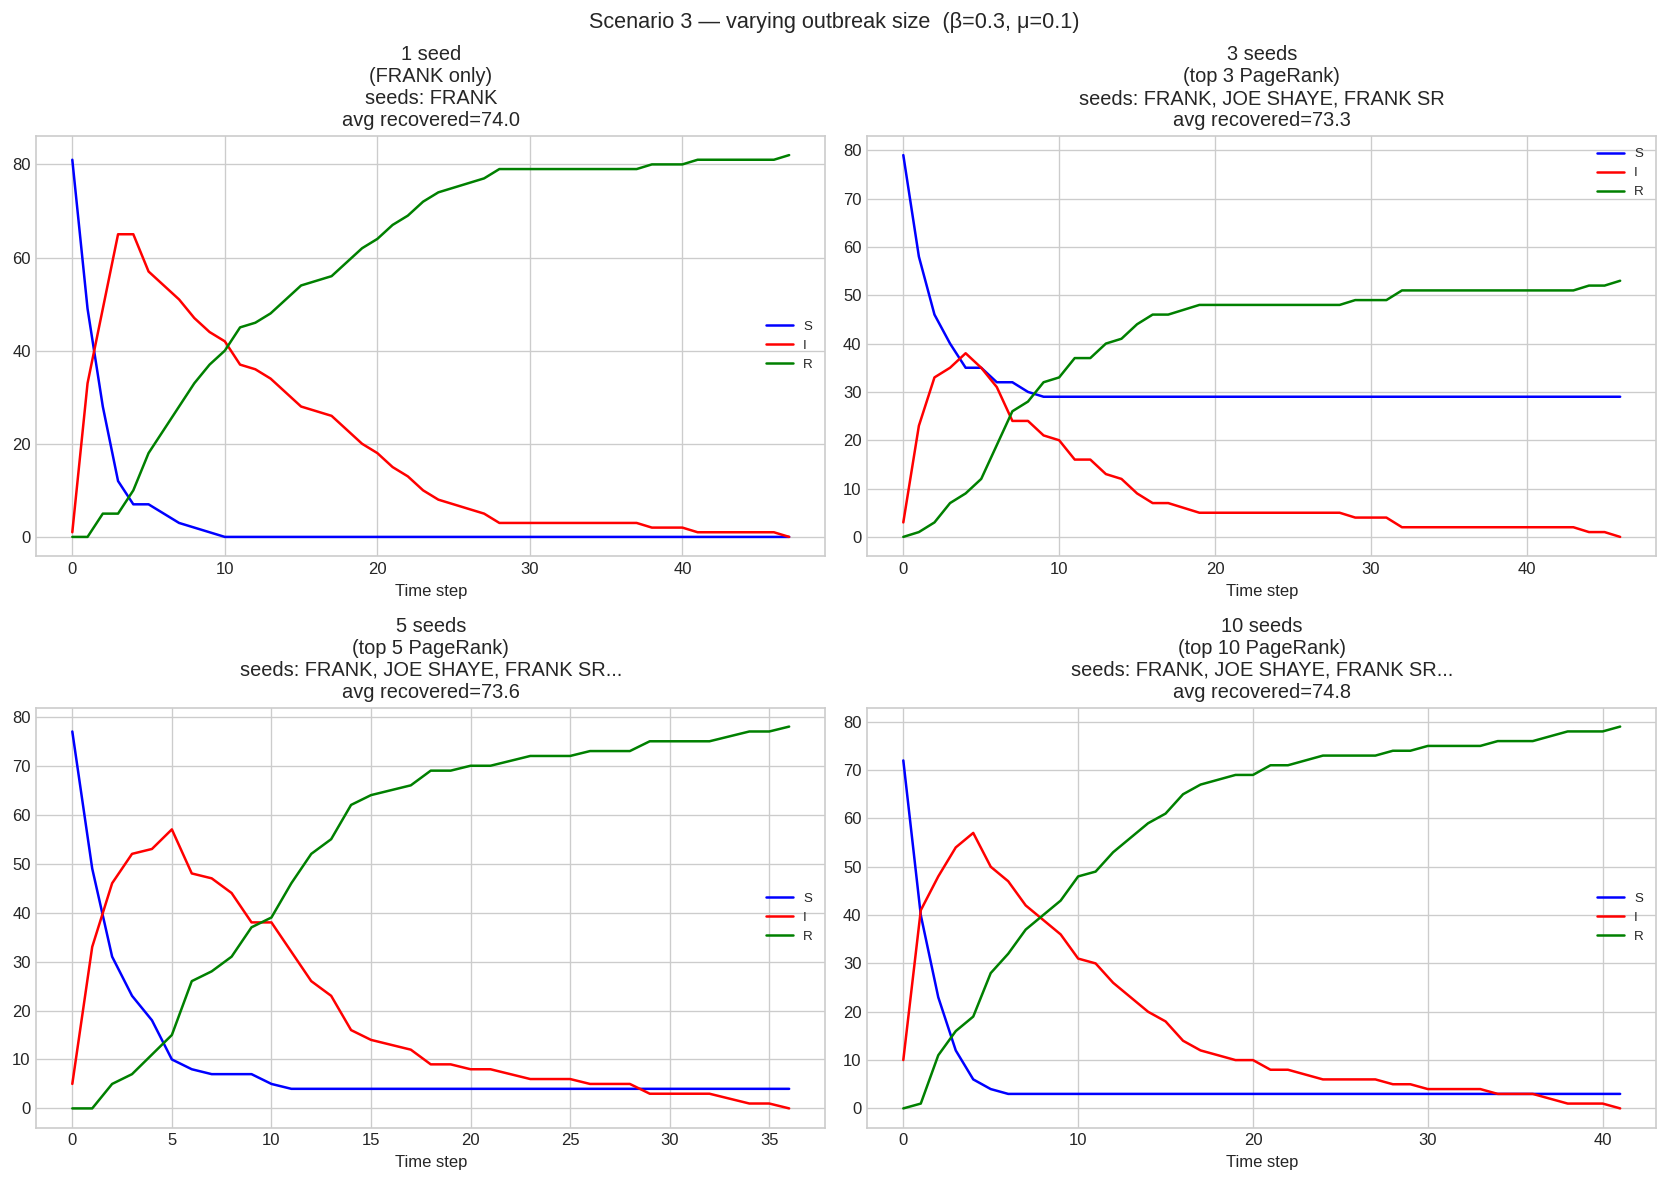

In [34]:
random.seed(42)
# see how much the initial number of infected nodes matters
T, beta, mu = 60, 0.3, 0.1
N_RUNS = 50

top_by_pr = centrality_df.sort_values('pagerank', ascending=False)['node'].astype(int).tolist()

outbreak_sets = {
    '1 seed\n(FRANK only)':              top_by_pr[:1],
    '3 seeds\n(top 3 PageRank)':         top_by_pr[:3],
    '5 seeds\n(top 5 PageRank)':         top_by_pr[:5],
    '10 seeds\n(top 10 PageRank)':       top_by_pr[:10],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (label, seeds) in zip(axes, outbreak_sets.items()):
    data_x, data_S, data_I, data_R = simulation_SIR(G, seeds, T, beta, mu)
    ax.plot(data_x, data_S, 'b', label='S')
    ax.plot(data_x, data_I, 'r', label='I')
    ax.plot(data_x, data_R, 'g', label='R')
    avg_r = avg_final_recovered(G, seeds, T, beta, mu, N_RUNS)
    seed_labels = ', '.join(G.nodes[n]['label'] for n in seeds[:3])
    if len(seeds) > 3:
        seed_labels += '...'
    ax.set_title(f'{label}\nseeds: {seed_labels}\navg recovered={avg_r:.1f}')
    ax.set_xlabel('Time step')
    ax.legend(fontsize=8)

plt.suptitle(f'Scenario 3 — varying outbreak size  (β={beta}, μ={mu})', fontsize=13)
plt.tight_layout()
plt.show()

### Comment

The three scenarios show that the network strongly favors widespread contagion. In **Scenario 1**, FRANK and JOE SHAYE both produce approximately **74/82** average recovered nodes, while even the peripheral character **LANDLORD** reaches **60/82**, indicating the epidemic size is relatively insensitive to the choice of origin. In **Scenario 2**, β has the strongest influence: high β with low μ leads to rapid near-total spread, while low β with high μ produces a self-limiting epidemic. **Scenario 3** shows that increasing the seed size yields only marginal gains: 10 seeds barely outperform 1, confirming that a single central node is already sufficient to trigger a near-total epidemic under moderate parameters.

## **Conclusion**

This project analyzed the character interaction network of *Catch Me If You Can* through a series of Social Network Analysis techniques, covering graph structure, clustering, centrality, communities, link prediction, random graph modeling, and contagion dynamics.

The network is **sparse** (82 nodes, 162 edges, density ≈ 0.049) yet surprisingly cohesive at the local level, with an average clustering coefficient of **0.599**, far higher than what a random or purely preferential-attachment model would predict. This tension between global sparsity and local cohesion is one of the most distinctive features of the network. **Frank Abagnale Jr.** emerges as the uncontested structural center across every measure: his betweenness centrality of **0.878** and PageRank of **0.223** confirm that virtually all information pathways in the network pass through him, a result consistent with his role as the movie's protagonist.

Community detection identified **7 communities** with a modularity of **0.432**, revealing that the cast naturally organizes into distinct narrative groups, each loosely connected through Frank. Link prediction confirmed this hub dominance: the strongest predicted missing link is **FRANK SR and JOE SHAYE**, two characters already close to Frank who share the most common neighbors.

The random graph analysis showed that a **Preferential Attachment with Triad Closure** model (p = 0.80) reproduces average degree and clustering well, but overestimates transitivity, suggesting that real movie networks contain a more hierarchical triangle structure than the model generates. Finally, the **SIR contagion simulations** revealed that the network is highly susceptible to epidemic-like spreading: even a single peripheral seed can ultimately infect over 75% of the cast, while starting from Frank offers only a marginal advantage over other origins, highlighting how the dense local clustering makes containment difficult regardless of where spreading begins.